# Difficulty Trend: COVID Years vs LLM Evolution Years

This notebook uses the merged broad-group quarter dataset, but keeps the difficulty signal simple: `RMP_Difficulty`.

The plot is split into two windows so the COVID trend and the later LLM-evolution trend can be compared directly.


In [10]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
project_root = next((path for path in [cwd, *cwd.parents] if (path / "src").exists() and (path / "data" / "capes_data.csv").exists()), None)
if project_root is None:
    raise FileNotFoundError("Could not find the project root from the current notebook working directory.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.difficulty_analysis import GROUP_DEPARTMENTS, resolve_project_root
from src.merged_trend_analysis import build_merged_group_quarter, build_rmp_difficulty_effects, plot_rmp_difficulty_windows


In [11]:
root_dir = resolve_project_root(project_root)
figure_dir = root_dir / "notebooks" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

merged = build_merged_group_quarter(root_dir)
group_effects = build_rmp_difficulty_effects(merged)

print("Groups used:")
for group, departments in GROUP_DEPARTMENTS.items():
    print(f"  {group}: {departments}")

group_effects.round(3)


Groups used:
  Engineering: ['CSE', 'ECE', 'MAE', 'SE', 'CENG', 'BENG']
  Biology: ['BILD', 'BIMM', 'BIBC', 'BICD', 'BIPN']
  Languages & Linguistics: ['LIGN', 'JAPN', 'CHIN', 'LTEN', 'LTWR']
  Social Sciences: ['ECON', 'PSYC', 'SOCI', 'POLI', 'COMM', 'USP']


Window,Group,COVID Window,LLM Window,LLM - COVID
0,Biology,3.553,3.409,-0.144
1,Engineering,3.652,3.578,-0.074
2,Languages & Linguistics,2.632,2.435,-0.197
3,Social Sciences,3.174,2.918,-0.256


## Side-by-Side Trend Comparison

Left: `2019-2021` window for the COVID years.
Right: `2022-2025` window for the LLM-evolution years.


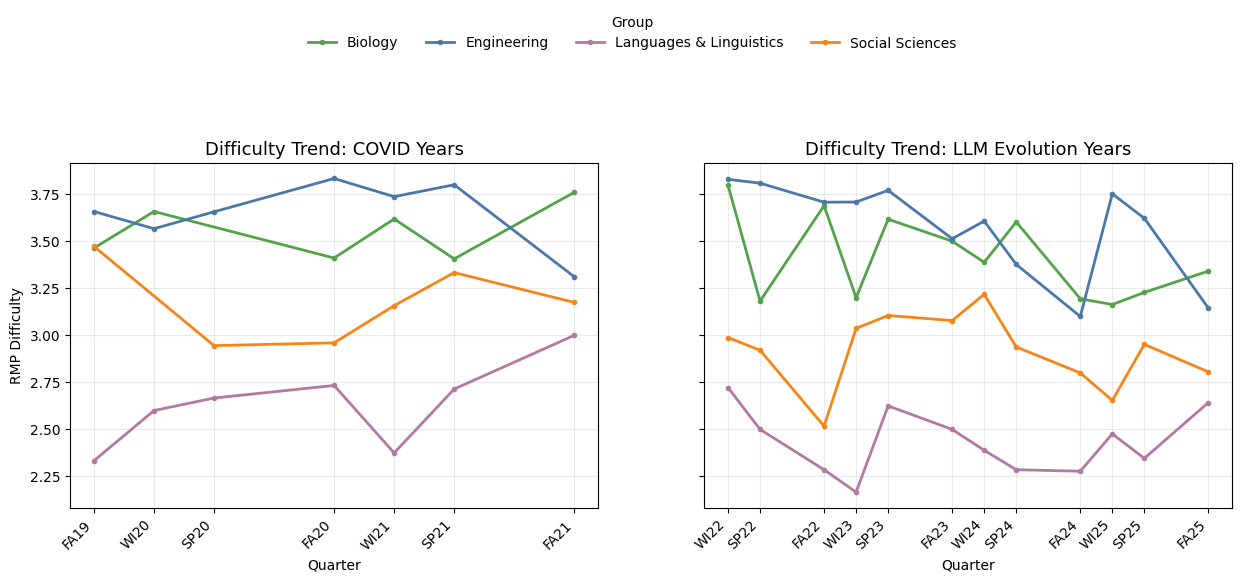

In [12]:
plot_path = figure_dir / "difficulty_group_trend_side_by_side.png"
plot_rmp_difficulty_windows(merged, plot_path)
